# ReAct-агент с нуля

Собираем голого ReAct-агента на чистом Python: цикл, три инструмента, счётчик денег.

Тезис: **хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.**  

## Ключ

**Локально.** Скопируйте `.env.example` в `.env` рядом с ноутбуком и впишите ключ в строку `OPENROUTER_API_KEY=`.

**В Kaggle.** Ключ кладут в Secrets:

1. Откройте ноутбук в Kaggle, в верхнем меню редактора выберите **Add-ons**, затем **Secrets**.
2. Нажмите **Add a new secret**. В поле Label впишите ровно `OPENROUTER_API_KEY`, в поле Value сам ключ, нажмите Save.
3. Убедитесь, что галочка напротив секрета включена: так он становится доступен этому ноутбуку.
4. В правой панели **Settings** включите **Internet**. Без подтверждённого телефона переключатель не работает: подтверждение в настройках профиля Kaggle.

Первая ячейка после установки пакетов прочитает секрет через `UserSecretsClient` и остановится с понятной ошибкой, если ключа нет.

In [49]:
import os, re, sys, json, time, ast, operator, subprocess
from pathlib import Path
from dataclasses import dataclass, field
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, ValidationError

try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
assert os.getenv("OPENROUTER_API_KEY"), "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
HEADERS = {"Authorization": f"Bearer {os.environ['OPENROUTER_API_KEY']}",
           "X-Title": "ai-agent-events"}
MODELS = {"cheap": "openai/gpt-4o-mini", "mid": "anthropic/claude-haiku-4.5", "strong": "anthropic/claude-sonnet-4.6"}
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = Path("data")

TRACES, IMG = Path("traces"), Path("img")
TRACES.mkdir(exist_ok=True)
IMG.mkdir(exist_ok=True)

## Спринт 1. Один вызов: цена и время

`Ledger` записывает каждый вызов: тег, модель, токены, стоимость и секунды. OpenRouter возвращает стоимость в поле `usage.cost`. `chat()` отправляет сообщения, замеряет время и кладёт `usage` в ledger.

Чекпоинт: график «цена против времени ответа» по трём моделям на одном вопросе. Сильная модель не только дороже, но и медленнее, и это вторая ось, о которой обычно забывают.

In [50]:
@dataclass
class Ledger:
    calls: list = field(default_factory=list)

    def add(self, tag, model, usage, seconds=0.0):
        p, c = usage.get("prompt_tokens", 0), usage.get("completion_tokens", 0)
        cost = usage.get("cost") or 0.0
        self.calls.append({"tag": tag, "model": model.split("/")[-1], "prompt": p, "completion": c,
                           "cost": cost, "seconds": round(seconds, 2)})
        return cost

    @property
    def total(self):
        return sum(c["cost"] for c in self.calls)

    def table(self):
        df = pd.DataFrame(self.calls)
        return df.groupby(["tag", "model"]).agg(calls=("cost", "size"), prompt=("prompt", "sum"),
                                                completion=("completion", "sum"), cost=("cost", "sum"),
                                                seconds=("seconds", "sum")).round(5)

ledger = Ledger()

`post_with_retry` обеспечивает доставку запроса удаленной модели на `OpenRouter` и получение ответа, а также переотправку запроса до получения успешного статус кода или исчерпания количества попыток.

In [130]:
def post_with_retry(body, attempts=3):
    for attempt in range(attempts):
        r = requests.post(CHAT_URL, json=body, headers=HEADERS, timeout=120)
        if r.status_code == 200:
            return r.json()
        if r.status_code in (429, 500, 502, 503) and attempt < attempts - 1:
            wait = r.headers.get("Retry-After")
            time.sleep(float(wait) if wait else 2 * 2 ** attempt)   # 2, 4, 8, 16 c
            continue
        raise RuntimeError(f"HTTP {r.status_code} : {r.text[:5000]}")

`chat` оформляет тело запроса с переданной историей диалога и тулами, отправляет его переданной модели с помощью `post_with_retry` и ведет учет запросов в `ledger`. 

In [52]:
def chat(messages, model, tools=None, tag="chat", temperature=None):
    body = {"model": model, "messages": messages, "usage": {"include": True}}
    if tools:
        body["tools"] = tools
        body["tool_choice"] = "auto"
    if temperature is not None:
        body["temperature"] = temperature
    started = time.perf_counter()
    data = post_with_retry(body)
    ledger.add(tag, model, data.get("usage") or {}, time.perf_counter() - started)
    return data["choices"][0]["message"]

Примеры использования:

In [5]:
msg = chat([{"role": "user", "content": "Ответь одним словом: какого цвета небо?"}], MODELS["cheap"], tag="hello")
msg["content"], ledger.calls[-1]

('Синее.',
 {'tag': 'hello',
  'model': 'gpt-4o-mini',
  'prompt': 18,
  'completion': 4,
  'cost': 5.1e-06,
  'seconds': 3.49})

In [6]:
question = [{"role": "user", "content": "Объясни в трёх предложениях, что такое контекстное окно языковой модели. Включи максимально подробное объяснение"}]
answers = {name: chat(question, model, tag="window")["content"] for name, model in MODELS.items()}
ledger.table().loc["window"]

,calls,prompt,completion,cost,seconds
model,,,,,
claude-haiku-4.5,1,48,266,0.00138,4.20
claude-sonnet-4.6,1,48,454,0.00695,19.32
gpt-4o-mini,1,35,134,0.00009,5.83


`cost_time_chart` для сравнения цены/времени ответа на запросы из истории `ledger`

In [53]:
def cost_time_chart(tag):
    df = pd.DataFrame([c for c in ledger.calls if c["tag"] == tag])
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    ax.scatter(df["cost"] * 100, df["seconds"], s=140, color=COLORS["violet"])
    for _, r in df.iterrows():
        ax.annotate(r["model"], (r["cost"] * 100, r["seconds"]), xytext=(8, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена ответа, центы (логарифмическая шкала)")
    ax.set_ylabel("время ответа, секунды")
    ax.grid(alpha=0.3)
    return fig

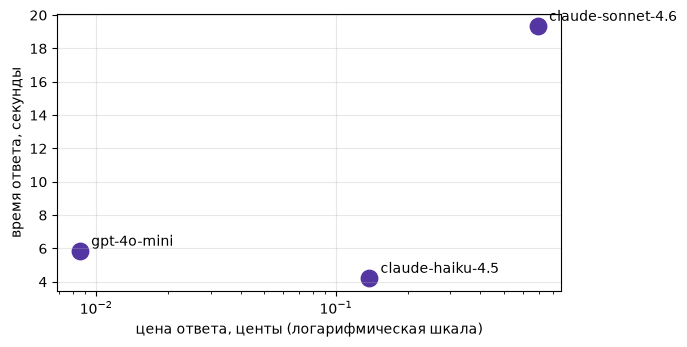

In [ ]:
cost_time_chart("window");

In [8]:
for name, text in answers.items():
    print(f"{name:7s}| {text[:230]}")

cheap  | Контекстное окно языковой модели — это ограниченный объем текста, который модель может учитывать одновременно при обработке и генерации языка. Этот объем определяется количеством токенов (слов или символов), которые модель может п
mid    | # Контекстное окно языковой модели

Контекстное окно — это максимальный объём текста (количество токенов), который модель может одновременно обрабатывать и учитывать при генерации ответа, включая как входной запрос пользователя, т
strong | ## Контекстное окно языковой модели

**Контекстное окно** — это максимальный объём текста (измеряемый в **токенах** — фрагментах слов длиной ~3–4 символа), который языковая модель способна одновременно «удерживать в памяти» и обра


## Спринт 2. Ответ по схеме и температура

Модель зачастую просят вернуть JSON по схеме Pydantic-модели. 
Ниже пример со схемой `Answer`. Схема уходит в системный промпт, ответ проверяется той же моделью. Если ответ не прошёл проверку, текст ошибки возвращается модели, и она пробует снова. Этот приём, ошибка обратно модели как текст, дальше держит весь цикл агента.

`json_from` вытаскивает первый объект из текста и разбирает его терпимо к переносам строк внутри значений: модели любят оборачивать JSON словами и писать рассуждение в несколько строк.

In [54]:
class Answer(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ: число или короткая фраза")

SCHEMA_PROMPT = "Отвечай строго одним JSON-объектом по этой схеме, без текста вокруг, строки в одну линию, без лишних отступов, \t, \n:\n{schema}"

def json_from(text):
    m = re.search(r"\{.*\}", text or "", re.S)
    if not m:
        raise ValueError("в ответе нет JSON")
    return json.loads(m.group(0), strict=False)

In [55]:
Answer.model_json_schema()

{'properties': {'reasoning': {'description': 'ход решения в два-три предложения',
   'title': 'Reasoning',
   'type': 'string'},
  'final': {'description': 'только итоговый ответ: число или короткая фраза',
   'title': 'Final',
   'type': 'string'}},
 'required': ['reasoning', 'final'],
 'title': 'Answer',
 'type': 'object'}

In [56]:
schema=Answer
SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))

'Отвечай строго одним JSON-объектом по этой схеме, без текста вокруг, строки в одну линию, без лишних отступов, \t, \n:\n{"properties": {"reasoning": {"description": "ход решения в два-три предложения", "title": "Reasoning", "type": "string"}, "final": {"description": "только итоговый ответ: число или короткая фраза", "title": "Final", "type": "string"}}, "required": ["reasoning", "final"], "title": "Answer", "type": "object"}'

`ask_structured` записывает дописывает схему в системный промт и валидирует с помощью `json_from` возвращение ответа в нужной форме.

In [57]:
def ask_structured(question, model, schema=Answer, attempts=3):
    messages = [
        {"role": "system", "content": SCHEMA_PROMPT.format(schema=json.dumps(schema.model_json_schema(), ensure_ascii=False))},
        {"role": "user", "content": question}
    ]
    for _ in range(attempts):
        msg = chat(messages, model, tag="struct")
        try:
            return schema.model_validate(json_from(msg["content"]))
        except (ValidationError, ValueError) as e:
            messages += [msg, {"role": "user", "content": f"Ответ не прошел проверку на структуру: {e}. Верни ответ по строгой JSON схеме"}]
    raise ValueError("Модель не справилась")

Влияние требований в схеме:

Схема `Numeric` требует число, а вопрос про столицу Франции: смотрим, сколько вызовов уйдёт и чем кончится. 

In [58]:
class Numeric(BaseModel):
    final: float = Field(description="ответ числом")

In [ ]:
calls_before = len(ledger.calls)
try:
    result_incorrect = ask_structured("Назови столицу Франции", MODELS["cheap"], Numeric)
    result_correct = ask_structured("Какой год основания Франции", MODELS["cheap"], Numeric)
except ValueError as e:
    result = e
print("вызовов потрачено:", len(ledger.calls) - calls_before, "| результат:")
print('incorrect question:', result_incorrect)
print('correct question:', result_correct)

вызовов потрачено: 2 | результат:
incorrect question: final=0.0
correct question: final=843.0


Влияние температуры:

И одна и та же просьба придумать название кофейни пять раз при температуре 0 и пять раз при 1.2.

In [15]:
prompt = [{"role": "user", "content": "Придумай название для кофейни рядом с университетом. Только название, два слова."}]
pd.DataFrame({f"temperature {t}": [chat(prompt, MODELS["cheap"], tag="temperature", temperature=t)["content"] for _ in range(5)]
              for t in (0.0, 1.2)})

,temperature 0.0,temperature 1.2
0,Кофейный Уголок,"""Кофе и знание"""
1,Кофейный Уголок,Студенческий Гурман
2,Кофейный Уголок,Кофейный Уголок
3,"""Кофе Ум""",Кофейный Уголок
4,Кофейный Уголок,"""Умный Кофе"""


## Спринт 3. Сравнение моделей на задачах

`compare_models` собирает таблицу статистики по запускам модели на группе задач-запросов. `compare_chart` позволяет готовую таблицу отобразить.

In [59]:
MONTHS = ["january", "february", "march", "april", "may", "june", "july", "august", "september", "october", "november", "december"]
RU_MONTHS = dict(zip(["январ", "феврал", "март", "апрел", "ма", "июн", "июл", "август", "сентябр", "октябр", "ноябр", "декабр"], MONTHS))
NUMBERS = {w: str(i) for i, w in enumerate("zero one two three four five six seven eight nine ten eleven twelve thirteen fourteen fifteen sixteen seventeen eighteen nineteen twenty".split())}
NUMBERS.update({w: str(10 * i) for i, w in enumerate("thirty forty fifty sixty seventy eighty ninety".split(), 3)})
NUMBERS.update({w: str(i) for i, w in enumerate("ноль один два три четыре пять шесть семь восемь девять десять одиннадцать двенадцать тринадцать четырнадцать пятнадцать шестнадцать семнадцать восемнадцать девятнадцать двадцать".split())})
NUMBERS.update({w: str(10 * i) for i, w in enumerate("тридцать сорок пятьдесят шестьдесят семьдесят восемьдесят девяносто".split(), 3)})
NUMBERS.update({"одна": "1", "две": "2"})
SCALES = {"thousand": 1e3, "тысяча": 1e3, "тысячи": 1e3, "тысяч": 1e3, "тыс": 1e3,
          "million": 1e6, "m": 1e6, "миллион": 1e6, "миллиона": 1e6, "миллионов": 1e6, "млн": 1e6,
          "billion": 1e9, "bn": 1e9, "миллиард": 1e9, "миллиарда": 1e9, "миллиардов": 1e9, "млрд": 1e9}

def normalize(text):
    text = str(text).lower().replace("ё", "е")
    text = re.sub(r"\b\d{1,3}(?:[ \u00a0\u202f]\d{3})+\b", lambda m: re.sub(r"\D", "", m[0]), text)
    text = re.sub(r"(\d),(?=\d{3}\b)", r"\1", text).replace(",", ".") if re.search(r"\d,\d", text) else text
    text = re.sub(r"\b(\d{4})-(\d{2})-(\d{2})\b", lambda m: f"{int(m[3])} {MONTHS[int(m[2]) - 1]} {m[1]}", text)
    text = re.sub(r"\b(" + "|".join(RU_MONTHS) + r")(?:я|а|е|ь|й)?\b", lambda m: RU_MONTHS[m[1]], text)
    text = re.sub(r"\b(" + "|".join(NUMBERS) + r")\b", lambda m: NUMBERS[m[1]], text)
    text = re.sub(r"(\d+(?:\.\d+)?)\s*(" + "|".join(SCALES) + r")(?!\w)", lambda m: str(round(float(m[1]) * SCALES[m[2]])), text)
    text = re.sub(r"(\d)(st|nd|rd|th|-?[а-я]{1,2})\b", r"\1", text)
    text = re.sub(r"(\d+)\.(\d+)", lambda m: m[1] + ("_" + m[2].rstrip("0") if m[2].strip("0") else ""), text)
    text = re.sub(r"(\d) of ", r"\1 ", text)
    text = re.sub(r"[^\w\s]", " ", text.replace(",", ""))
    text = re.sub(r"\b(a|an|the)\b", " ", text)
    text = re.sub(r"\b(" + "|".join(MONTHS) + r") (\d{1,2})\b", r"\2 \1", " ".join(text.split()))
    return text

def is_correct(task, answer):
    if task["source"] == "gsm8k":
        nums = re.findall(r"-?\d+(?:\.\d+)?", str(answer).replace(",", ""))
        return bool(nums) and abs(float(nums[-1]) - float(task["answer"])) < 1e-6
    gold, answer = normalize(task["answer"]), normalize(answer)
    number = re.fullmatch(r"(?:at least |about |over |more than )?(\d+(?:_\d+)?)(?: [^\W\d]+)*", gold)
    if number and not any(m in gold for m in MONTHS):
        return number[1] in answer.split()
    return gold in answer

def summary(config, model, n, correct, cost, steps, seconds=0.0):
    return {"config": config, "model": model.split("/")[-1], "n": n, "accuracy": round(correct / n, 2),
            "cost_per_task": round(cost / n, 5), "cost_per_correct": round(cost / correct, 5) if correct else float("inf"),
            "avg_steps": round(steps, 2), "avg_seconds": round(seconds, 1)}

def compare_models(tasks, models):
    rows = []
    for name, model in models.items():
        before, correct, started = ledger.total, 0, time.perf_counter()
        for task in tasks:
            try:
                correct += is_correct(task, ask_structured(task["question"], model).final) #ожидаем ответ по схеме Answer
            except Exception:
                pass
        rows.append(summary("без инструментов, JSON", model, len(tasks), correct, ledger.total - before, 1,
                            (time.perf_counter() - started) / len(tasks)))
    return pd.DataFrame(rows)

def compare_chart(df):
    fig, axes = plt.subplots(1, 3, figsize=(11, 3.4))
    axes[0].bar(df["model"], df["accuracy"] * 100, color=COLORS["violet"])
    axes[0].set_ylabel("доля верных, %")
    axes[0].set_ylim(0, 105)
    axes[1].bar(df["model"], df["cost_per_correct"] * 100, color=COLORS["amber"])
    axes[1].set_ylabel("цена верного ответа, центы")
    axes[2].bar(df["model"], df["avg_seconds"], color=COLORS["teal"])
    axes[2].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.tick_params(axis="x", labelrotation=12)
        ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    return fig

Доработка проверки ответа: `is_correct` засчитывает ответ, если нормализованный эталон в нём содержится, а `normalize` приводит к одному виду числа и даты, в том числе по-русски, потому что системный промпт русский и модель может ответить «15 марта» на английский вопрос:

- даты: `March 15, 2026`, `15th of March`, `2026-03-15` и `15 марта 2026 года` превращаются в `15 march 2026`, поэтому эталон `15 March` находится в любом из них;
- числа словами становятся цифрами: `nine`, `девять` → `9`, `Thirty thousand`, `30 тысяч` → `30000`;
- множители раскрываются: `1.7 million`, `1,7 млн`, `8.15m`, `£30.4bn` → целое число, как и `1,700,000` и `700 000`;
- десятичная запятая равна точке: `238,28` = `238.28`, а запятая перед тремя цифрами считается разделителем тысяч;
- порядковые окончания и нули в конце дроби убираются: `11th`, `11-е` → `11`, `146.70` → `146.7`; `ё` заменяется на `е`;
- если эталон это число с единицами (`28 people`, `41.5 °C`, `at least six`), достаточно, чтобы это число стояло в ответе отдельным словом: `28` засчитывается, а `21` внутри `2021` нет.

In [17]:
assert is_correct({"source": "fresh", "answer": "15 March"}, "FINAL: March 15, 2026")
assert is_correct({"source": "fresh", "answer": "20 January 2025"}, "2025-01-20")
assert not is_correct({"source": "fresh", "answer": "15 March"}, "April 15")
assert is_correct({"source": "fresh", "answer": "nine"}, "9")
assert is_correct({"source": "fresh", "answer": "Thirty thousand people"}, "30,000")
assert is_correct({"source": "fresh", "answer": "£30.4bn"}, "£30.4 billion")
assert is_correct({"source": "fresh", "answer": "28 people"}, "28")
assert is_correct({"source": "fresh", "answer": "146.70"}, "146.7")
assert not is_correct({"source": "fresh", "answer": "21"}, "2021")
assert not is_correct({"source": "fresh", "answer": "13.2 months"}, "13")
assert is_correct({"source": "fresh", "answer": "15 March"}, "15 марта 2026 года")
assert is_correct({"source": "fresh", "answer": "Thirty thousand people"}, "30 тысяч человек")
assert is_correct({"source": "fresh", "answer": "238.28"}, "238,28 балла")
assert is_correct({"source": "fresh", "answer": "700,000"}, "700 000")
assert is_correct({"source": "fresh", "answer": "тулуп"}, "четверной тулуп")
assert is_correct({"source": "hotpot", "answer": "Scott Derrickson"}, "FINAL: Scott Derrickson")
"is_correct работает"

'is_correct работает'

In [60]:
def load_tasks(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

## Спринт 4. Цикл ReAct

Название из статьи Yao et al. (2022): модель чередует рассуждение и действие, а после каждого действия получает наблюдение. В текущем варианте рассуждение живёт внутри модели, а действия это вызовы инструментов через `tool_calls`.

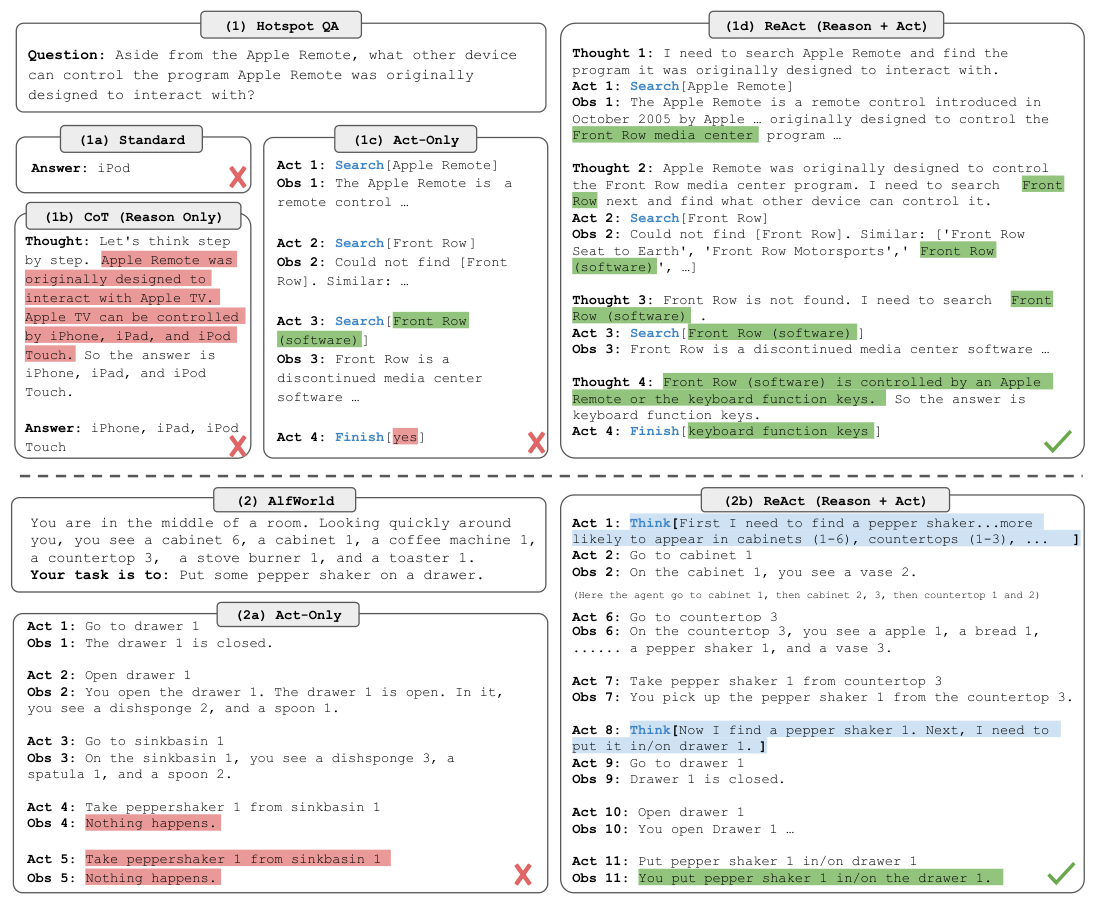

*Yao et al., 2022. ReAct: на одном вопросе из HotpotQA видно, почему рассуждение вместе с действиями выигрывает у каждого по отдельности*

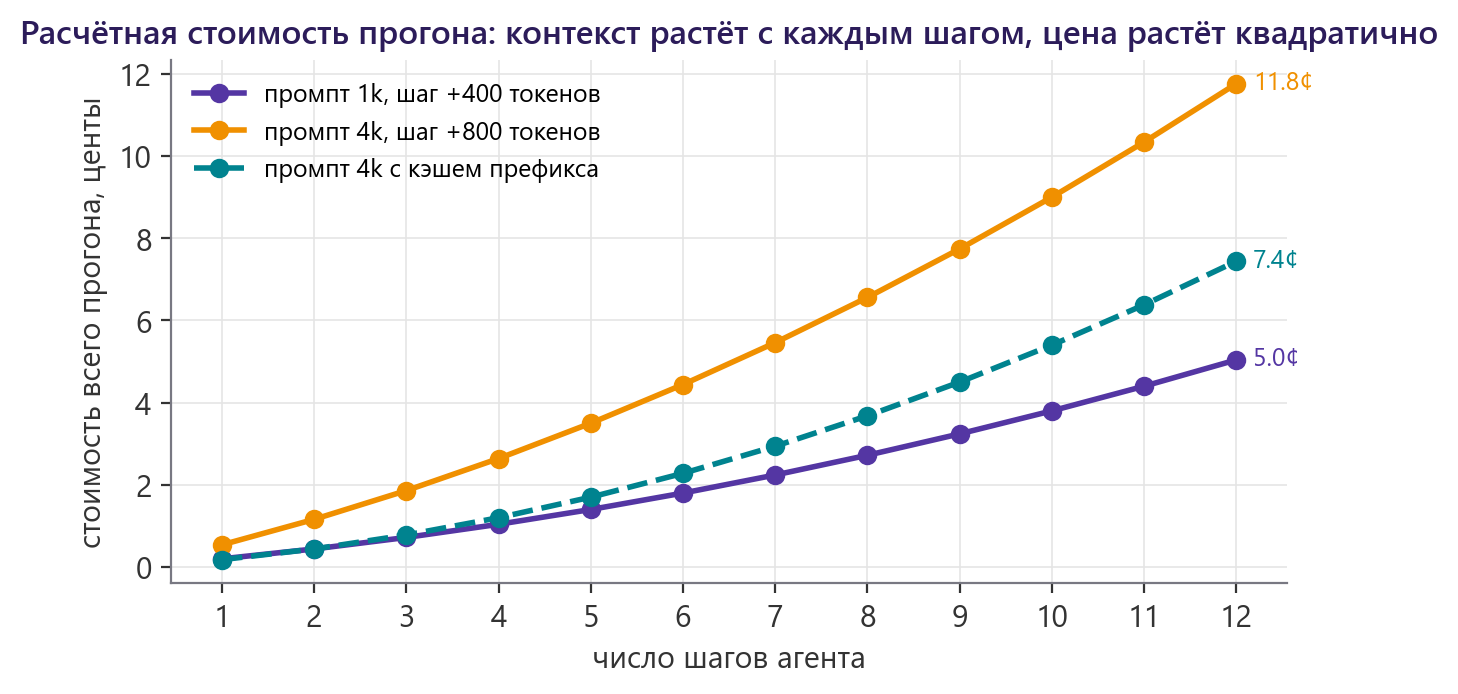

*Контекст накапливается, и четыре шага агента стоят как восемь одиночных вызовов*

Инструмент регистрируется функцией `register(fn, args_model, description)`: схема параметров берётся из Pydantic-модели, ею же потом проверяются аргументы, которые прислала модель. 

Инструмент `Калькулятор` написан через `ast`.

In [61]:
TOOLS = {}

def register(fn, args_model, description):
    TOOLS[fn.__name__] = {"fn": fn, "args": args_model, "schema": {"type": "function", "function": {
        "name": fn.__name__, "description": description, "parameters": args_model.model_json_schema()}}}

OPS = {ast.Add: operator.add, ast.Sub: operator.sub, ast.Mult: operator.mul, ast.Div: operator.truediv,
       ast.Pow: operator.pow, ast.USub: operator.neg, ast.Mod: operator.mod}

def evaluate(node):
    if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
        return node.value
    if isinstance(node, ast.BinOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.left), evaluate(node.right))
    if isinstance(node, ast.UnaryOp) and type(node.op) in OPS:
        return OPS[type(node.op)](evaluate(node.operand))
    raise ValueError("допустимы только числа и арифметика")

class CalcArgs(BaseModel):
    expr: str = Field(description="арифметическое выражение, например 17*23+5")

def calculator(expr: str) -> str:
    try:
        val = evaluate(ast.parse(expr.replace(",", "."), mode="eval").body)
        return str(int(val)) if float(val).is_integer() else f"{val:.4f}".rstrip("0")
    except Exception as e:
        return f"ошибка вычисления: {e}"

register(calculator, CalcArgs, "Считает арифметическое выражение: числа, скобки, + - * / ** %")
json.dumps(TOOLS["calculator"]["schema"], ensure_ascii=False, indent=1)

'{\n "type": "function",\n "function": {\n  "name": "calculator",\n  "description": "Считает арифметическое выражение: числа, скобки, + - * / ** %",\n  "parameters": {\n   "properties": {\n    "expr": {\n     "description": "арифметическое выражение, например 17*23+5",\n     "title": "Expr",\n     "type": "string"\n    }\n   },\n   "required": [\n    "expr"\n   ],\n   "title": "CalcArgs",\n   "type": "object"\n  }\n }\n}'

Агенту будем подавать `SYSTEM` промт с указанием явного финального ответа. 

**Замечание:** в `SYSTEM` добавлено «на языке вопроса, имена и названия пиши как в источнике». Промпт русский, а вопросы в основном английские, и модель может ответить по-русски («СПбГУ», «Моне Тиба»), тогда как эталон английский. Числа и даты на обоих языках выравнивает `normalize`, а имена и названия без перевода не сравнить, поэтому язык ответа задаётся в промпте.

Для написания цикла агента вводится `Run` контейнер для трекинга метаданных о каждом вызове и хранения истории диалога (обращение по API - stateless, каждый раз необходимо отправлять полный диалог).

`looped` позволяет определить повторяющийся ли агент просит вызов тула.
`finish` даёт агенту последний вызов без инструментов, когда сработало стоп-условие, `show_trace` печатает историю по шагам.

In [62]:
SYSTEM = ("Ты решаешь задачи. Если нужно посчитать или найти факт, вызывай инструменты, а не угадывай. "
          "Когда ответ готов, напиши его последней строкой в формате FINAL: <ответ>. "
          "Для числовых задач в FINAL только число, для вопросов о фактах короткая фраза "
          "на языке вопроса, имена и названия пиши как в источнике.")

@dataclass
class Run:
    question: str
    answer: str
    steps: int
    messages: list
    cost: float = 0.0
    seconds: float = 0.0

def looped(seen, calls):
    keys = [(c["function"]["name"], c["function"]["arguments"]) for c in calls]
    repeated = any(k in seen for k in keys)
    seen.update(keys)
    return repeated

def finish(model, messages, step):
    del messages[-1]
    messages.append({"role": "user", "content": "Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>."})
    msg = chat(messages, model, tag="agent")
    messages.append(msg)
    return msg.get("content") or "", step + 1


`run_tool` обеспечивает выполнение одного вызова инструмента.

In [63]:
def run_tool(call):
    name = call["function"]["name"]

    try:
        spec = TOOLS[name]
        args = spec["args"].model_validate_json(call["function"]["arguments"])
        result = spec["fn"](**args.model_dump())
    except Exception as e:
        result = f"НЕ удалось вызвать инструмент {name}: {e}"
    return {"role": "tool", "tool_call_id" : call["id"], "content": str(result)[:2000]}


`agent_loop` обеспечивает цикл `ReAct` агента - формирует json запроса через `chat` и обращается к `OpenRouter` по API для получения ответа. Сохраняется ответ в диалоге и вызывает тулы, избегая повторов. Считается, что если модель не вызвала тул, то она выдала финальный ответ.

In [64]:
def agent_loop(messages, model, tool_names, max_steps):
    seen = set()
    for step in range(1, max_steps + 1):
        msg = chat(messages, model, tools=[TOOLS[n]["schema"] for n in tool_names] or None, tag='agent')
        messages.append(msg)
        calls = msg.get("tool_calls") or []

        if not calls:
            return msg.get("content") or "", step
        if looped(seen, calls) or step == max_steps:
            return finish(model, messages, step)

        messages += [run_tool(c) for c in calls]


Обёртка `agent` замеряет цену и время.

In [65]:
def agent(question, model, tool_names, max_steps=8):
    messages = [{"role": "system", "content": SYSTEM}, {"role": "user", "content": question}]
    before, started = ledger.total, time.perf_counter()
    answer, steps = agent_loop(messages, model, tool_names, max_steps)
    return Run(question, answer, steps, messages, ledger.total - before, time.perf_counter() - started)

def show_trace(run):
    for m in run.messages[1:]:
        calls = "; ".join(f"{c['function']['name']}{c['function']['arguments']}" for c in m.get("tool_calls") or [])
        text = " ".join((m.get("content") or "").split())[:180]
        print(f"{m['role']:9s}| {text} {calls}")
    print(f"шагов: {run.steps}, цена: {run.cost * 100:.3f} ¢, время: {run.seconds:.1f} c")

Демонстрация работы агента с переданным тулом-калькулятором:

In [24]:
run = agent("Сколько будет 17 * 23 + 5? Посчитай инструментом.", MODELS["cheap"], ["calculator"])
show_trace(run)

user     | Сколько будет 17 * 23 + 5? Посчитай инструментом. 
assistant|  calculator{"expr":"17*23+5"}
tool     | 396 
assistant| FINAL: 396 
шагов: 2, цена: 0.007 ¢, время: 2.9 c


In [25]:
run = agent("Посчитай площадь круга радиусом 3 (пи возьми 3.14159) и объём куба со стороной 4. Верни оба числа.", MODELS["cheap"], ["calculator"])
show_trace(run)
[len(m.get("tool_calls") or []) for m in run.messages if m["role"] == "assistant"]

user     | Посчитай площадь круга радиусом 3 (пи возьми 3.14159) и объём куба со стороной 4. Верни оба числа. 
assistant|  calculator{"expr": "3.14159 * (3 ** 2)"}; calculator{"expr": "4 ** 3"}
tool     | 28.2743 
tool     | 64 
assistant| FINAL: 28.2743, 64 
шагов: 2, цена: 0.011 ¢, время: 6.1 c


[2, 0]

Демонстрации работы с инструментом, имитирующим поломку:

In [66]:
class BrokenArgs(BaseModel):
    query: str = Field(description="любой запрос")

def broken_search(query: str) -> str:
    return "ошибка: сервис недоступен, попробуйте ещё раз"

register(broken_search, BrokenArgs, "Ищет ответ на любой вопрос в интернете")

In [ ]:
run = agent("Кто написал роман «Мы»? Обязательно проверь через broken_search.", MODELS["cheap"], ["broken_search"], max_steps=8)
show_trace(run)

user     | Кто написал роман «Мы»? Обязательно проверь через broken_search. 
assistant|  broken_search{"query":"роман «Мы» автор"}
tool     | ошибка: сервис недоступен, попробуйте ещё раз 
user     | Инструменты больше недоступны. Ответь по тому, что уже известно, последней строкой FINAL: <ответ>. 
assistant| Роман «Мы» написан Евгением Замятином. FINAL: Евгений Замятин 
шагов: 3, цена: 0.012 ¢, время: 9.9 c


In [67]:
def flaky_search(query: str) -> str:
    return "ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова"

register(flaky_search, BrokenArgs, "Ищет ответ на любой вопрос в интернете")

In [ ]:
run_flaky = agent("Кто написал роман «Мы»? Обязательно проверь через flaky_search, пока не получишь результат.", MODELS["cheap"], ["flaky_search"], max_steps=8)
show_trace(run_flaky)

user     | Кто написал роман «Мы»? Обязательно проверь через flaky_search, пока не получишь результат. 
assistant|  flaky_search{"query":"кто написал роман Мы"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"автор романа Мы"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query":"кто является автором романа Мы"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant|  flaky_search{"query": "кто написал роман Мы"}; flaky_search{"query": "автор романа Мы"}; flaky_search{"query": "кто является автором романа Мы"}
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
tool     | ошибка: сервис перегружен, переформулируйте запрос и попробуйте снова 
assistant| Не удалось получить информацию о романе «Мы» из-за перегрузк

График демострации роста контекста: 

In [68]:
def context_chart(run):
    calls = [c for c in ledger.calls if c["tag"] == "agent"][-run.steps:]
    steps = range(1, len(calls) + 1)
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.plot(steps, [c["prompt"] for c in calls], marker="o", color=COLORS["violet"], label="токены на входе")
    ax.plot(steps, [c["completion"] for c in calls], marker="o", color=COLORS["amber"], label="токены на выходе")
    ax.set_xlabel("шаг агента")
    ax.set_ylabel("токены за вызов")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

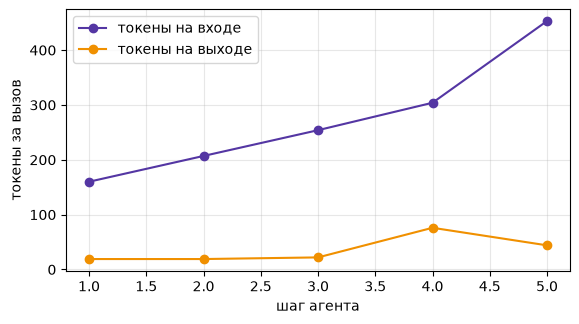

In [ ]:
context_chart(run_flaky);

## Спринт 5. Инструменты

Модель выбирает инструмент по имени и описанию, поэтому у каждого инструмента внятное описание и Pydantic-модель с описанием каждого поля. Это не оформление, это часть промпта.

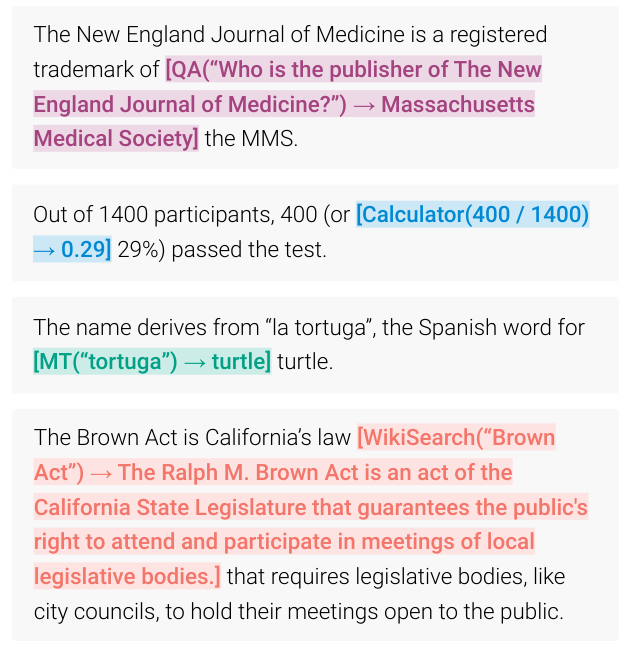

*Schick et al., 2023. Toolformer: модель сама вставляет вызовы калькулятора, поиска и календаря прямо в текст.*

### Базовые инструменты


Запрос к Википедии с повтором при троттлинге дан готовым в `wiki`. 

In [69]:
WIKI = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "ai-agent-events/0.1 (https://github.com/NorthMarshmallo)"}

def wiki(params, attempts=3):
    for attempt in range(attempts):
        try:
            r = requests.get(WIKI, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=15)
            if r.status_code == 200 and r.headers.get("content-type", "").startswith("application/json"):
                return r.json()["query"]
            error = f"ответила {r.status_code}"
        except requests.RequestException as e:
            error = f"недоступна: {type(e).__name__}"
        time.sleep(1.0 + attempt)
    raise RuntimeError(f"Википедия {error}")

class SearchArgs(BaseModel):
    query: str = Field(description="короткий поисковый запрос: имя, название, термин")

class ExecArgs(BaseModel):
    code: str = Field(description="код на Python; результат надо напечатать через print")

`web_search` - тул поиска по википедии с аргументом запроса, который соответствует схеме `SearchArgs`.


In [70]:
def web_search(query: str) -> str:
    hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 1})["search"]

    if not hits:
        return "No data"
    pages = wiki({"action":"query", "prop": "extracts", "explaintext": 1, "exintro": 1, "titles": hits[0]["title"]})["pages"]
    text = " ".join(next(iter(pages.values())).get("extract", "").split())
    return f"[{hits[0]["title"]}] {text[:5000]}"

`python_exec` - тул исполнения python кода с аргументом текста кода, который соответствует схеме `ExecArgs`.


Ошибки инструмента возвращаются модели текстом. Например, `ZeroDivisionError` в выводе это нормальный результат, модель его прочитает и поправит код: 

Код запускается в отдельном процессе. Если он падает с 1/0, traceback с ZeroDivisionError пишется в stderr. capture_output=True его перехватывает, а строка r.stdout + r.stderr склеивает с обычным выводом.

Отдельный процесс и таймаут как минимум изоляции.

In [71]:
def python_exec(code: str) -> str:
    try:
        r = subprocess.run([sys.executable, "-I", "-c", code], capture_output=True, text=True, timeout=5)
    except subprocess.TimeoutExpired:
        return "Код превысил 5 сек"
    out = (r.stdout + r.stderr).strip()
    return out[:5000] if out else "Код исполнился но результат пустой"


In [32]:
python_exec("import time; time.sleep(10)")

'Код превысил 5 сек'

Каждый инструмент проверяется на трёх случаях: нормальный вход, пустой результат, ошибка. 

In [91]:
register(web_search, SearchArgs, "Ищет статью в англоязычной Википедии и возвращает её вступление")
register(python_exec, ExecArgs, "Выполняет код на Python в отдельном процессе и возвращает то, что он напечатал")

In [ ]:

assert calculator("2+2") == "4"
assert calculator("2**10") == "1024"
assert "ошибка" in calculator("__import__('os')")
assert web_search("Scott Derrickson").startswith("[Scott Derrickson]")
assert web_search("qwxzv 1234567 nonsense") == "No data"
assert python_exec("print(sum(range(10)))") == "45"
assert "ZeroDivisionError" in python_exec("1/0")
assert "Код превысил 5 сек" in python_exec("import time; time.sleep(10)")
"инструменты работают"

'инструменты работают'

Смотрим, что возвращает Википедия на неоднозначные запросы: 

In [34]:
for q in ["Ed Wood", "Ed Wood film", "Kiss and Tell 1945 film"]:
    print(q, "->", web_search(q)[:220], "\n")

Ed Wood -> [Ed Wood] Edward Davis Wood Jr. (October 10, 1924 – December 10, 1978) was an American filmmaker, actor and novelist. In the 1950s, Wood directed several low-budget science fiction, crime and horror films that later beca 

Ed Wood film -> [Ed Wood (film)] Ed Wood is a 1994 American biographical film directed and produced by Tim Burton and starring Johnny Depp as the eponymous cult filmmaker. The film concerns the period in Wood's life when he made his bes 

Kiss and Tell 1945 film -> [Kiss and Tell (1945 film)] Kiss and Tell is a 1945 American comedy film starring then 17-year-old Shirley Temple as Corliss Archer. In the film, two teenage girls cause their respective parents much concern when they st 



 Задаем вопрос на тему, ответ на который модели должен быть неизвестен и даем ей доступ к веб-поиску:

user     | кто выиграл женский US Open 2026 по теннису 
assistant|  web_search{"query":"2026 US Open women's tennis champion"}
tool     | [2026 US Open (tennis)] The 2026 US Open was the 146th edition of tennis' US Open, and the fourth and final Grand Slam event of the year. It was held on the outdoor hard courts at  
assistant|  web_search{"query":"2026 US Open women's singles winner"}
tool     | [2026 US Open (tennis)] The 2026 US Open was the 146th edition of tennis' US Open, and the fourth and final Grand Slam event of the year. It was held on the outdoor hard courts at  
assistant|  web_search{"query":"2026 US Open women singles champion"}
tool     | [2026 US Open – Women's singles] Elena Rybakina defeated two-time defending champion Aryna Sabalenka in the final, 6–4, 5–7, 6–2 to win the women's singles tennis title at the 2026 
assistant| Женский US Open 2026 выиграла Елена Рыбакина, обыграв в финале двухкратную чемпионку Арину Сабаленку со счетом 6–4, 5–7, 6–2. FINAL: Елена Рыба

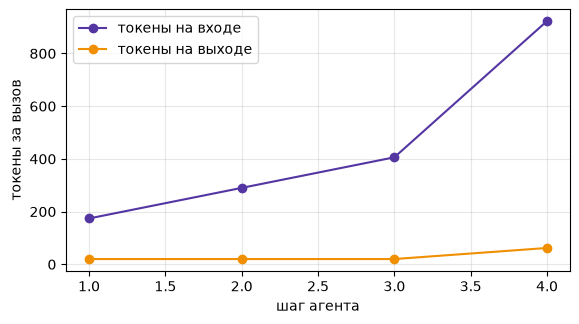

In [36]:
run = agent("кто выиграл женский US Open 2026 по теннису", MODELS["cheap"], ["web_search"])
show_trace(run)
context_chart(run);

### Дополнительные инструменты

Поиск по остальным источникам из `fresh_2026.jsonl`: русская Википедия, GEN и ESPN. Как и `web_search`, каждый возвращает `[название] начало статьи`. У сайтов разный API, поэтому получение статьи у каждого своё, а запрос с повтором и очистка HTML общие.

In [73]:
import html
from typing import Literal

PAGE_HEADERS = WIKI_HEADERS
RU_WIKI = "https://ru.wikipedia.org/w/api.php"

def get_page(url, site, params=None, attempts=3):
    for attempt in range(attempts):
        try:
            r = requests.get(url, params=params, headers=PAGE_HEADERS, timeout=15)
            if r.status_code == 200:
                return r
            error = f"ответил {r.status_code}"
        except requests.RequestException as e:
            error = f"недоступен: {type(e).__name__}"
        time.sleep(1.0 + attempt)
    raise RuntimeError(f"{site} {error}")

def clean(markup):
    markup = re.sub(r"(?s)<(style|script)[^>]*>.*?</\1>", "", markup)
    return " ".join(html.unescape(re.sub(r"<[^>]+>", " ", markup)).split())

def en_wiki_article(title):
    page = next(iter(wiki({"action": "query", "prop": "extracts", "explaintext": 1, "redirects": 1, "titles": title})["pages"].values()))
    return None if "missing" in page else (page["title"], page.get("extract", ""))

def ru_wiki_article(title):
    page = get_page(RU_WIKI, "Русская Википедия", {"action": "parse", "page": title, "prop": "text", "redirects": 1, "format": "json", "formatversion": 2}).json()
    if "parse" not in page:
        return None
    return page["parse"]["title"], clean(page["parse"]["text"]).replace("[ править | править код ]", "")

def gen_article(query):
    posts = get_page("https://www.genengnews.com/wp-json/wp/v2/posts", "GEN", {"search": query, "orderby": "relevance", "per_page": 5, "_fields": "title,content"}).json()
    if not posts:
        return None
    post = next((p for p in posts if clean(p["title"]["rendered"]) == query), posts[0])
    return clean(post["title"]["rendered"]), clean(post["content"]["rendered"])

def espn_article(query):
    results = get_page("https://site.web.api.espn.com/apis/search/v2", "ESPN", {"query": query, "limit": 5}).json().get("results", [])
    articles = [c for r in results if r.get("type") == "article" for c in r["contents"]]
    if not articles:
        return None
    article = next((a for a in articles if a["displayName"] == query), articles[0])
    paragraphs = re.findall(r"(?s)<p[^>]*>(.*?)</p>", get_page(article["link"]["web"], "ESPN").text)
    return article["displayName"], clean(" ".join(paragraphs))

def preview(article):
    return f"[{article[0]}] {article[1][:5000]}" if article else "No data"

def ru_wiki_search(query: str) -> str:
    hits = get_page(RU_WIKI, "Русская Википедия", {"action": "query", "list": "search", "srsearch": query, "srlimit": 1, "format": "json"}).json()["query"]["search"]
    return preview(ru_wiki_article(hits[0]["title"]) if hits else None)

def gen_search(query: str) -> str:
    return preview(gen_article(query))

def espn_search(query: str) -> str:
    return preview(espn_article(query))

register(ru_wiki_search, SearchArgs, "Ищет статью в русской Википедии и возвращает название и начало статьи. Запрос пишется по-русски, продолжение статьи ищи через page_find с site=ru_wiki")
register(gen_search, SearchArgs, "Ищет статью на GEN (Genetic Engineering & Biotechnology News) про биотех и AI в биологии и возвращает название и начало статьи. Запрос пишется по-английски, продолжение статьи ищи через page_find с site=gen")
register(espn_search, SearchArgs, "Ищет спортивную новость на ESPN и возвращает название и начало статьи. Запрос пишется по-английски, продолжение статьи ищи через page_find с site=espn")

In [ ]:
assert ru_wiki_search("Аделия Петросян").startswith("[Петросян, Аделия Тиграновна]")
assert "тулуп" in ru_wiki_search("Аделия Петросян")
assert "Аделия Петросян 235,95" in ru_wiki_search("Чемпионат России по фигурному катанию 2026")
assert ru_wiki_search("qwxzv 1234567 бессмыслица") == "No data"
assert "1.7 million" in gen_search("Proteina-Complexa")
assert gen_search("qwxzv 1234567 nonsense") == "No data"
assert "238.28" in espn_search("Kaori Sakamoto world title")
assert espn_search("qwxzv 1234567 nonsense") == "No data"
try:
    get_page("https://qwxzv.invalid", "Тестовый сайт", attempts=2)
except RuntimeError as e:
    assert str(e) == "Тестовый сайт недоступен: ConnectionError"
else:
    assert False, "get_page должен упасть"
assert "НЕ удалось" in run_tool({"id": "1", "function": {"name": "espn_search", "arguments": "{}"}})["content"]
"дополнительные инструменты работают"

'дополнительные инструменты работают'

`page_find` ищет по полному тексту статьи, а не по вступлению: факты о 2026 годе лежат в теле длинных обзорных страниц вроде «2026 in Japan». Модель сначала находит статью поиском, затем передаёт в `page_find` название из квадратных скобок, ключевые слова и сайт, и получает только предложения, где эти слова встречаются.

In [75]:
ARTICLES = {"en_wiki": en_wiki_article, "ru_wiki": ru_wiki_article, "gen": gen_article, "espn": espn_article}

class FindArgs(BaseModel):
    title: str = Field(description="название статьи из квадратных скобок в ответе поиска, например 2026 in Japan")
    keywords: list[str] = Field(description="ключевые слова для поиска предложений в статье: имена, места, даты, например ['Haneda', 'August 24']")
    site: Literal["en_wiki", "ru_wiki", "gen", "espn"] = Field("en_wiki", description="откуда статья: en_wiki после web_search, ru_wiki после ru_wiki_search, gen после gen_search, espn после espn_search")

def page_find(title: str, keywords: list[str], site: str = "en_wiki") -> str:
    article = ARTICLES[site](title)
    if not article:
        return f"Статья {title} не найдена"
    sentences = re.split(r"(?<=[.!?])\s+|\n+", article[1])
    found = [s for s in sentences if any(k.lower() in s.lower() for k in keywords)]
    return "\n".join(found) if found else "No data"

register(page_find, FindArgs, "Ищет предложения с ключевыми словами в полном тексте статьи, которую нашёл инструмент поиска. Нужна, когда во вступлении из поиска ответа нет: передай название статьи из квадратных скобок и сайт, где она найдена")

In [ ]:
assert "injuring nine people" in page_find("2026 in Japan", ["Haneda"])
assert "5.6" in page_find("2026 in Japan", ["yamanashi"])
assert page_find("2026 in Japan", ["qwxzv1234567"]) == "No data"
assert page_find("Qwxzv 1234567 nonsense", ["2026"]) == "Статья Qwxzv 1234567 nonsense не найдена"
assert "четверного тулупа" in page_find("Петросян, Аделия Тиграновна", ["тулуп"], "ru_wiki")
assert "Oak HC/FT" not in gen_search("Chai Series B")
assert "Oak HC/FT" in page_find("Chai’s the Limit for AI Antibody Designer After $130M Series B Funding", ["co-led"], "gen")
assert "Mone Chiba" in page_find("Kaori Sakamoto wins 4th world figure skating title before retirement", ["Chiba"], "espn")
assert "НЕ удалось" in run_tool({"id": "1", "function": {"name": "page_find", "arguments": '{"title": "2026 in Japan"}'}})["content"]
assert "НЕ удалось" in run_tool({"id": "2", "function": {"name": "page_find", "arguments": '{"title": "2026 in Japan", "keywords": ["Haneda"], "site": "bbc"}'}})["content"]
"page_find работает"

'page_find работает'

В конце регистрируем `tool_a` и `tool_b`: те же инструменты, но с описанием «Инструмент» и полем без описания, для дальнейших экспериментов:

In [76]:
class BlankArgs(BaseModel):
    text: str

def tool_a(text: str) -> str:
    return calculator(text)

def tool_b(text: str) -> str:
    return python_exec(text)

register(tool_a, BlankArgs, "Инструмент")
register(tool_b, BlankArgs, "Инструмент")
json.dumps(TOOLS["tool_b"]["schema"], ensure_ascii=False)

'{"type": "function", "function": {"name": "tool_b", "description": "Инструмент", "parameters": {"properties": {"text": {"title": "Text", "type": "string"}}, "required": ["text"], "title": "BlankArgs", "type": "object"}}}'

## Спринт 6. Прогон, трейсы, деньги

`final_answer` ищет финальный ответ по паттерну `FINAL:`, поскольку такой `SYSTEM` промт мы задавали в обертке `agent`.

`run_tasks` прогоняет список задач в одной конфигурации, считает цену, время и число вызовов инструментов на задачу, проверяет ответ и пишет трейс в `traces/<конфигурация>/<модель>/<id>.json`. `report` сводит результаты в таблицу с главной колонкой курса `cost_per_correct`. `money_chart` рисует цену задачи против доли верных: левый верхний угол это «дёшево и хорошо», туда мы и хотим попасть. `steps_chart` показывает шаги, вызовы инструментов и секунды по конфигурациям.

`CONFIGS` задает различные варианты конфигурации тулов.

In [155]:
def final_answer(text):
    m = re.search(r"FINAL:\s*(.+)", text or "")
    return m.group(1).strip() if m else (text or "").strip()

def trace_row(config, model, task, t):
    msgs = t["messages"]
    return {"config": config, "model": model.split("/")[-1], "id": task["id"], "source": task["source"],
            "correct": is_correct(task, final_answer(t["answer"])),
            "steps": sum(m["role"] == "assistant" for m in msgs),
            "tool_calls": sum(m["role"] == "tool" for m in msgs),
            "tools": ",".join(sorted({c["function"]["name"] for m in msgs for c in m.get("tool_calls") or []})),
            "cost": t["cost"], "seconds": t.get("seconds", float("nan")),
            "answer": final_answer(t["answer"])[:60], "gold": task["answer"]}

def run_tasks(tasks, model, tool_names, config, rerun=False):
    folder = TRACES / config / model.split("/")[-1]
    folder.mkdir(parents=True, exist_ok=True)
    rows = []
    for task in tasks:
        path = folder / f"{task['id']}.json"
        if path.exists() and not rerun:
            t = json.loads(path.read_text(encoding="utf-8"))
            if t["messages"]:                       # удачный прогон: берём из трейса, API не зовём
                rows.append(trace_row(config, model, task, t))
                continue
        try:
            run = agent(task["question"], model, tool_names)
        except Exception as e:
            run = Run(task["question"], f"ошибка: {e!r}", 0, [])
        t = {"task": task, "answer": run.answer, "cost": run.cost, "seconds": round(run.seconds, 1),
             "messages": run.messages}
        path.write_text(json.dumps(t, ensure_ascii=False, indent=1), encoding="utf-8")
        rows.append(trace_row(config, model, task, t))
        print(rows[-1])
    return pd.DataFrame(rows)

def report(results):
    rows = [summary(config, model, len(df), int(df["correct"].sum()), df["cost"].sum(), df["steps"].mean(), df["seconds"].mean())
            for (config, model), df in results.groupby(["config", "model"])]
    return pd.DataFrame(rows).sort_values("cost_per_task").reset_index(drop=True)

def money_chart(table, path="img/money_quality.png", title=""):
    fig, ax = plt.subplots(figsize=(8, 5))
    for _, r in table.iterrows():
        color = COLORS["red"] if "каскад" in r["config"] else COLORS["amber"] if "sonnet" in r["model"] else COLORS["violet"]
        ax.scatter(r["cost_per_task"] * 100, r["accuracy"] * 100, s=110, color=color)
        ax.annotate(f"{r['config']}\n{r['model']}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    fontsize=8, xytext=(6, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("цена задачи, центы (логарифмическая шкала)")
    ax.set_ylabel("доля верных ответов, %")
    ax.grid(alpha=0.3)
    ax.set_title(title)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

def steps_chart(results):
    g = results.groupby("config").agg(steps=("steps", "mean"), tool_calls=("tool_calls", "mean"), seconds=("seconds", "mean"))
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
    g[["steps", "tool_calls"]].plot.bar(ax=axes[0], color=[COLORS["violet"], COLORS["teal"]], rot=12)
    axes[0].set_ylabel("в среднем на задачу")
    g["seconds"].plot.bar(ax=axes[1], color=COLORS["amber"], rot=12)
    axes[1].set_ylabel("секунд на задачу")
    for ax in axes:
        ax.grid(alpha=0.3, axis="y")
        ax.set_xlabel("")
    fig.tight_layout()
    return fig

CONFIGS = {"без инструментов": [], "калькулятор": ["calculator"], "код": ["python_exec"], "поиск": ["web_search"],
           "поиск все источники": ["web_search", "ru_wiki_search", "gen_search", "espn_search"], 
           "поиск все источники + page_find": ["web_search", "ru_wiki_search", "gen_search", 
                                               "espn_search", "page_find"]}

In [156]:
TOOLS.keys()

dict_keys(['calculator', 'broken_search', 'flaky_search', 'ru_wiki_search', 'gen_search', 'espn_search', 'page_find', 'tool_a', 'tool_b', 'web_search', 'python_exec'])

In [157]:
VARIANTS = [("strong", "без инструментов"),                  # строка, которую надо обогнать
            ("cheap",  "без инструментов"),                  # честный ноль
            ("cheap",  "поиск"),                             # базовый агент с поиском
            ("cheap",  "поиск все источники + page_find"),
            ("mid",  "поиск все источники + page_find")]   # поиск и чтение страницы

In [158]:
tasks = load_tasks("fresh_2026.jsonl")[:27] + load_tasks("fresh_2026.jsonl")[125:]

results = pd.concat([run_tasks(tasks, MODELS[m], CONFIGS[c], c) for m, c in VARIANTS], ignore_index=True)

нет трейсов: поиск все источники + page_find / claude-haiku-4.5 — 98 из 155


,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,без инструментов,gpt-4o-mini,155,0.03,0.00004,0.00133,1.00,7.9
1,поиск,gpt-4o-mini,155,0.27,0.00054,0.00201,4.55,51.0
2,поиск все источники + page_find,gpt-4o-mini,155,0.44,0.00089,0.00203,4.88,42.1
3,без инструментов,claude-sonnet-4.6,155,0.04,0.00221,0.05719,1.00,10.2
4,поиск все источники + page_find,claude-haiku-4.5,57,0.56,0.03069,0.05466,4.79,46.0


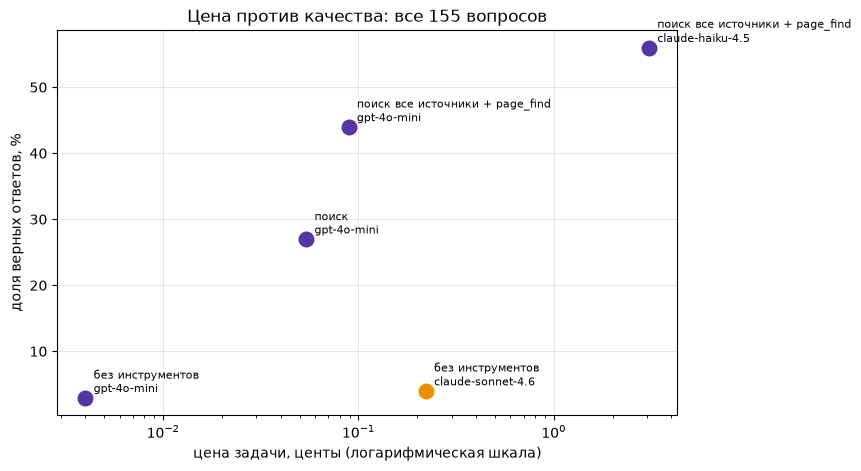

In [179]:
tasks = load_tasks("fresh_2026.jsonl")

def load_results(tasks, variants):
    rows, missing = [], {}
    for m, c in variants:
        model = MODELS[m]
        folder = TRACES / c / model.split("/")[-1]
        for task in tasks:
            path = folder / f"{task['id']}.json"
            t = json.loads(path.read_text(encoding="utf-8")) if path.exists() else None
            if t and t["messages"]:
                rows.append(trace_row(c, model, task, t))
            else:
                key = f"{c} / {model.split('/')[-1]}"
                missing[key] = missing.get(key, 0) + 1
    for key, n in missing.items():
        print(f"нет трейсов: {key} — {n} из {len(tasks)}")
    return pd.DataFrame(rows)

def to_md(df, path):
    lines = ["| " + " | ".join(df.columns) + " |", "|" + "---|" * len(df.columns)]
    cell = lambda v: f"{v:.5f}".rstrip("0").rstrip(".") if isinstance(v, float) else str(v)
    lines += ["| " + " | ".join(map(cell, r)) + " |" for r in df.itertuples(index=False)]
    Path(f"{IMG}/{path}").write_text("\n".join(lines) + "\n", encoding="utf-8")

results = load_results(tasks, VARIANTS)
results.to_csv(f"{IMG}/results_raw.csv", index=False)
table = report(results)
to_md(table, "results_table.md")
money_chart(table, title=f"Цена против качества: все {results['id'].nunique()} вопросов")
table

К сожалению, средняя модель начала потреблять много кредитов, поэтому в итоговые таблицы разделены на 57 общих вопросов и 155 вопросов, на которых прогонялись только первые 4 варианта.

Для 57 общих вопросов составляем подробную сводку: какой вариант в каких задачах справился. Берём только задачи, которые прогнаны у всех вариантов (общие вопросы).

Средняя модель вместо дешёвой, те же инструменты, 57 вопросов:
  верных ответов: 27 → 32 (+5): решила 12 новых, потеряла 7
  потрачено: $0.049 → $1.749, в 36 раз больше
  один верный ответ дешёвой стоит $0.0018, а каждый добавленный средней — $0.340


,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,без инструментов,gpt-4o-mini,57,0.04,0.00004,0.00121,1.00,9.3
1,поиск,gpt-4o-mini,57,0.25,0.00062,0.00251,4.86,50.5
2,поиск все источники + page_find,gpt-4o-mini,57,0.47,0.00086,0.00182,4.91,39.1
3,без инструментов,claude-sonnet-4.6,57,0.05,0.00238,0.04530,1.00,7.8
4,поиск все источники + page_find,claude-haiku-4.5,57,0.56,0.03069,0.05466,4.79,46.0


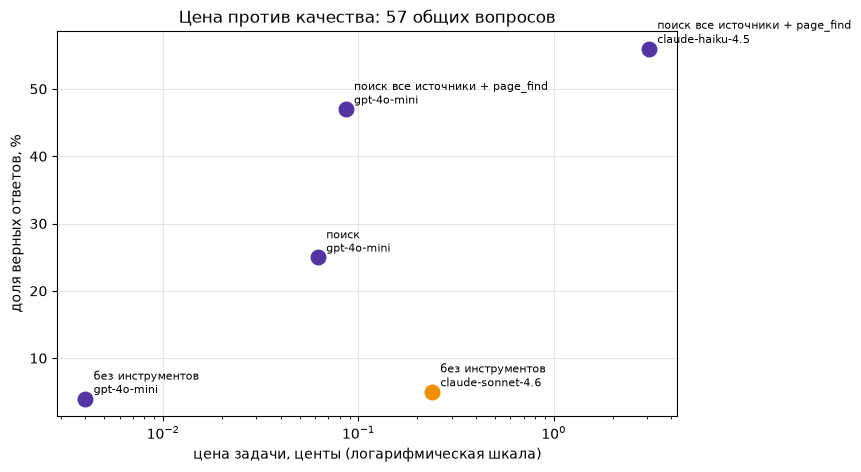

In [183]:
# общие задачи: есть удачный трейс у всех вариантов
res = results.assign(variant=results["model"] + " | " + results["config"])
wide = res.pivot_table(index="id", columns="variant", values="correct", aggfunc="first").dropna().astype(bool)
common = wide.index
n = len(common)

table_common = report(results[results["id"].isin(common)])
to_md(table_common, "results_table_common.md")
money_chart(table_common, path=IMG / "money_quality_common.png", title=f"Цена против качества: {n} общих вопросов")

# сколько стоит переход с дешёвой модели на среднюю с теми же инструментами
ch, md = (f"{MODELS[k].split('/')[-1]} | поиск все источники + page_find" for k in ("cheap", "mid"))
spent = res[res["id"].isin(common)].groupby("variant")["cost"].sum()
extra = int(wide[md].sum() - wide[ch].sum())
print(f"Средняя модель вместо дешёвой, те же инструменты, {n} вопросов:\n"
      f"  верных ответов: {wide[ch].sum()} → {wide[md].sum()} (+{extra}): решила {(wide[md] & ~wide[ch]).sum()} новых, потеряла {(wide[ch] & ~wide[md]).sum()}\n"
      f"  потрачено: ${spent[ch]:.3f} → ${spent[md]:.3f}, в {spent[md] / spent[ch]:.0f} раз больше\n"
      f"  один верный ответ дешёвой стоит ${spent[ch] / wide[ch].sum():.4f}, "
      f"а каждый добавленный средней — ${(spent[md] - spent[ch]) / extra:.3f}")
table_common


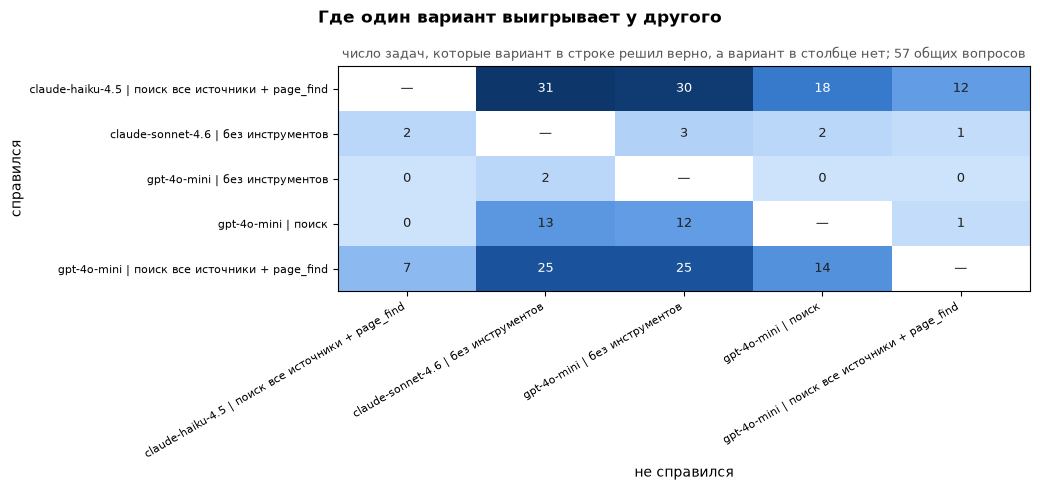

In [181]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])

def heatmap(df, title, subtitle, xlabel, ylabel, fmt="{:.0f}", path=None):
    vals = df.to_numpy(dtype=float)
    fig, ax = plt.subplots(figsize=(1.5 * df.shape[1] + 3, 0.55 * df.shape[0] + 2.2))
    ax.imshow(vals, cmap=BLUES, aspect="auto")
    lo, hi = np.nanmin(vals), np.nanmax(vals)
    for i, j in np.ndindex(vals.shape):
        v = vals[i, j]
        dark = hi > lo and (v - lo) / (hi - lo) > 0.55
        ax.text(j, i, "—" if np.isnan(v) else fmt.format(v), ha="center", va="center",
                fontsize=9, color="white" if dark else "#1f1f1f")
    ax.set_xticks(range(df.shape[1]), df.columns, rotation=30, ha="right", fontsize=8)
    ax.set_yticks(range(df.shape[0]), df.index, fontsize=8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.suptitle(title, fontweight="bold")
    ax.set_title(subtitle, fontsize=9, color="#555")
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

# кто решил то, чего не решил другой
wins = pd.DataFrame({a: {b: (wide[a] & ~wide[b]).sum() for b in wide.columns} for a in wide.columns}).T.astype(float)
for c in wins.columns:
    wins.loc[c, c] = np.nan
heatmap(wins, "Где один вариант выигрывает у другого",
        f"число задач, которые вариант в строке решил верно, а вариант в столбце нет; {n} общих вопросов",
        "не справился", "справился", path=IMG / "wins.png");


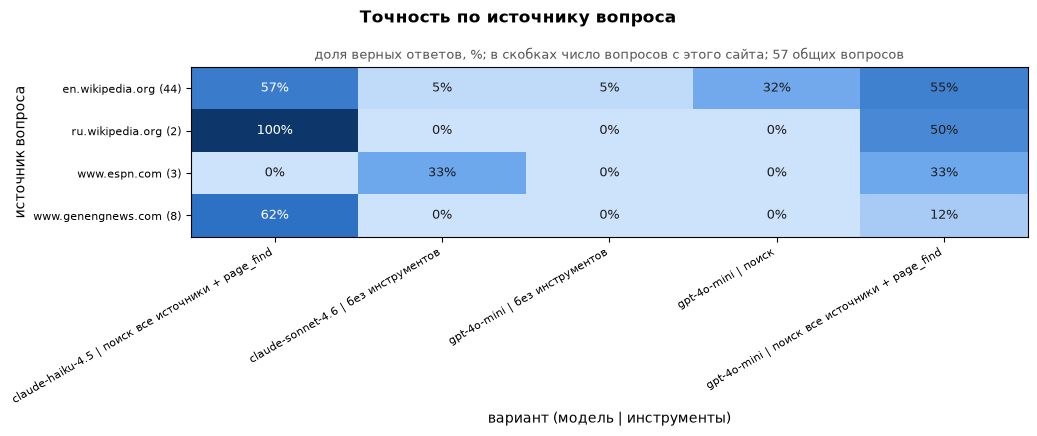

In [182]:
# точность по источнику вопроса
site = {t["id"]: t["url"].split("/")[2] for t in tasks}
rc = res[res["id"].isin(common)].assign(site=lambda d: d["id"].map(site))
counts = rc.drop_duplicates("id")["site"].value_counts()
acc = rc.pivot_table(index="site", columns="variant", values="correct", aggfunc="mean") * 100
acc.index = [f"{s} ({counts[s]})" for s in acc.index]
heatmap(acc, "Точность по источнику вопроса",
        f"доля верных ответов, %; в скобках число вопросов с этого сайта; {n} общих вопросов",
        "вариант (модель | инструменты)", "источник вопроса", fmt="{:.0f}%", path=IMG / "by_site.png");


Как часто вариант берётся за каждый инструмент: в ячейке процент задач, где инструмент вызвали хотя бы раз. Прочерк значит, что в этой конфигурации такого инструмента нет. Нижняя строка показывает, в скольких задачах модель вообще полезла в инструменты, а не ответила по памяти.

Колонка `tools` появилась в `trace_row`, поэтому перед этой ячейкой перезапустите ячейку с `trace_row` и ячейку с `load_results`.

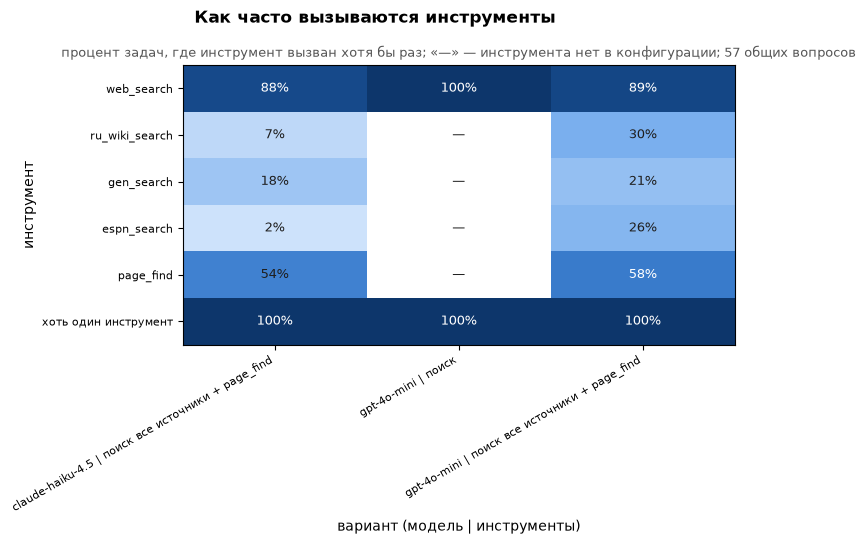

In [164]:
rt = res[res["id"].isin(common) & (res["config"] != "без инструментов")]
cfg = rt.drop_duplicates("variant").set_index("variant")["config"]
names = list(dict.fromkeys(t for c in cfg for t in CONFIGS[c]))
usage = pd.DataFrame({v: {t: g["tools"].str.contains(t).mean() * 100 if t in CONFIGS[cfg[v]] else np.nan for t in names}
                      for v, g in rt.groupby("variant")})
usage.loc["хоть один инструмент"] = rt.groupby("variant")["tool_calls"].apply(lambda s: (s > 0).mean() * 100)
heatmap(usage, "Как часто вызываются инструменты",
        f"процент задач, где инструмент вызван хотя бы раз; «—» — инструмента нет в конфигурации; {n} общих вопросов",
        "вариант (модель | инструменты)", "инструмент", fmt="{:.0f}%", path=IMG / "tool_usage.png");


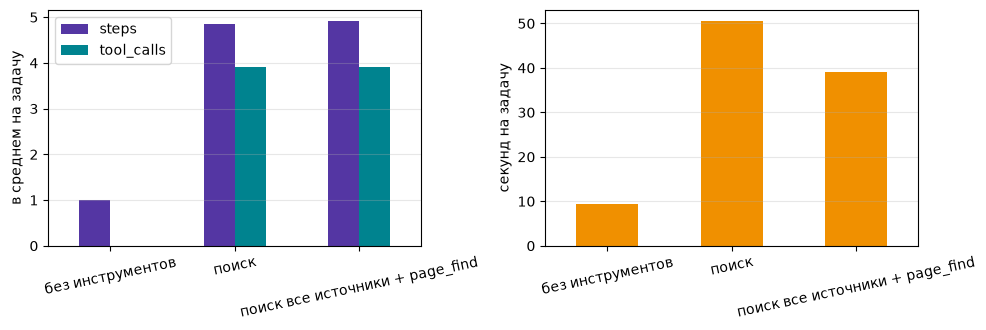

In [166]:
steps_chart(results[results["model"] == "gpt-4o-mini"]).savefig(IMG / "steps.png", dpi=150, bbox_inches="tight")

In [167]:
trace = json.loads(next((TRACES / "поиск" / "gpt-4o-mini").glob("fresh-*.json")).read_text(encoding="utf-8"))
show_trace(Run(trace["task"]["question"], trace["answer"], sum(m["role"] == "assistant" for m in trace["messages"]), trace["messages"], trace["cost"]))

user     | What was the location of the boat capsizing in Japan in March 2026? 
assistant|  web_search{"query":"boat capsizing in Japan March 2026"}
tool     | [Capsizing] Capsizing or keeling over occurs when a boat or ship is rolled on its side or further by wave action, instability or wind force beyond the angle of positive static stab 
assistant|  web_search{"query":"boat capsizing Japan March 2026 news"}
tool     | [List of shipwrecks in 2026] The list of shipwrecks in 2026 includes ships sunk, foundered, grounded, or otherwise lost during 2026. 
assistant|  web_search{"query":"Japan boat capsizing March 2026 details"}
tool     | [Capsizing] Capsizing or keeling over occurs when a boat or ship is rolled on its side or further by wave action, instability or wind force beyond the angle of positive static stab 
assistant|  web_search{"query":"Japan boat accident March 2026"}
tool     | [List of aviation shootdowns and accidents during the 2026 Iran war] This is a list of aviation sho

In [168]:
ledger.table(), round(ledger.total, 3)

(                         calls   prompt  completion     cost   seconds
 tag   model                                                           
 agent claude-haiku-4.5     292  1628467       29696  1.77695   1780.41
       claude-sonnet-4.6    155    23690       18136  0.34311   1579.70
       gpt-4o-mini         1729  1725337       54023  0.23449  11394.22,
 2.355)

## Спринт 7. Каскад: дешёвая модель первой, сильная по необходимости

Идея FrugalGPT в самом простом виде. Дешёвая модель отвечает и заявляет уверенность от 0 до 1 (схема `Confident`). Если уверенность ниже порога, задача уходит сильной модели. `confident_answer` запоминает ответы каждой модели по задаче, поэтому развёртка по порогам не делает лишних вызовов: каждая модель спрашивается один раз на задачу, дальше арифметика.

`cascade_sweep` считает точность, цену задачи и долю задач, ушедших наверх, для нескольких порогов: порог 0 это только дешёвая модель, порог 1.01 это сильная плюс потраченный впустую вызов дешёвой. `cascade_chart` рисует кривую цена против точности. `confidence_chart` показывает, чему верить: гистограмма заявленной уверенности отдельно для верных и неверных ответов.

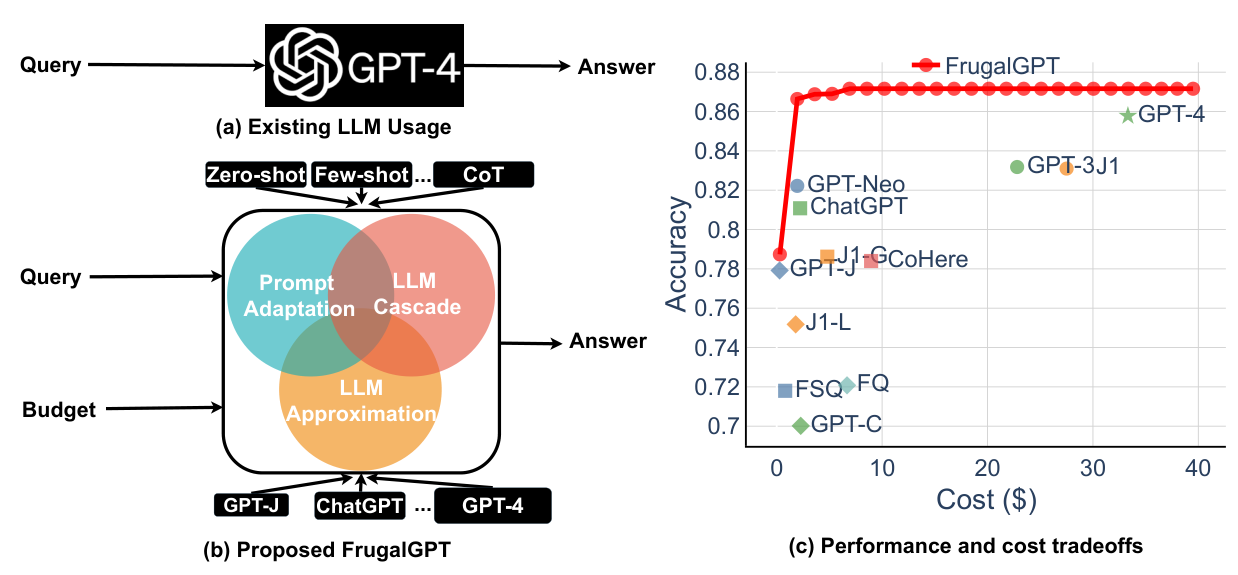

*Chen, Zaharia, Zou, 2023. FrugalGPT: каскад из дешёвых и сильных моделей достигает точности GPT-4 при цене в разы ниже. Красная линия это тезис курса одной картинкой*

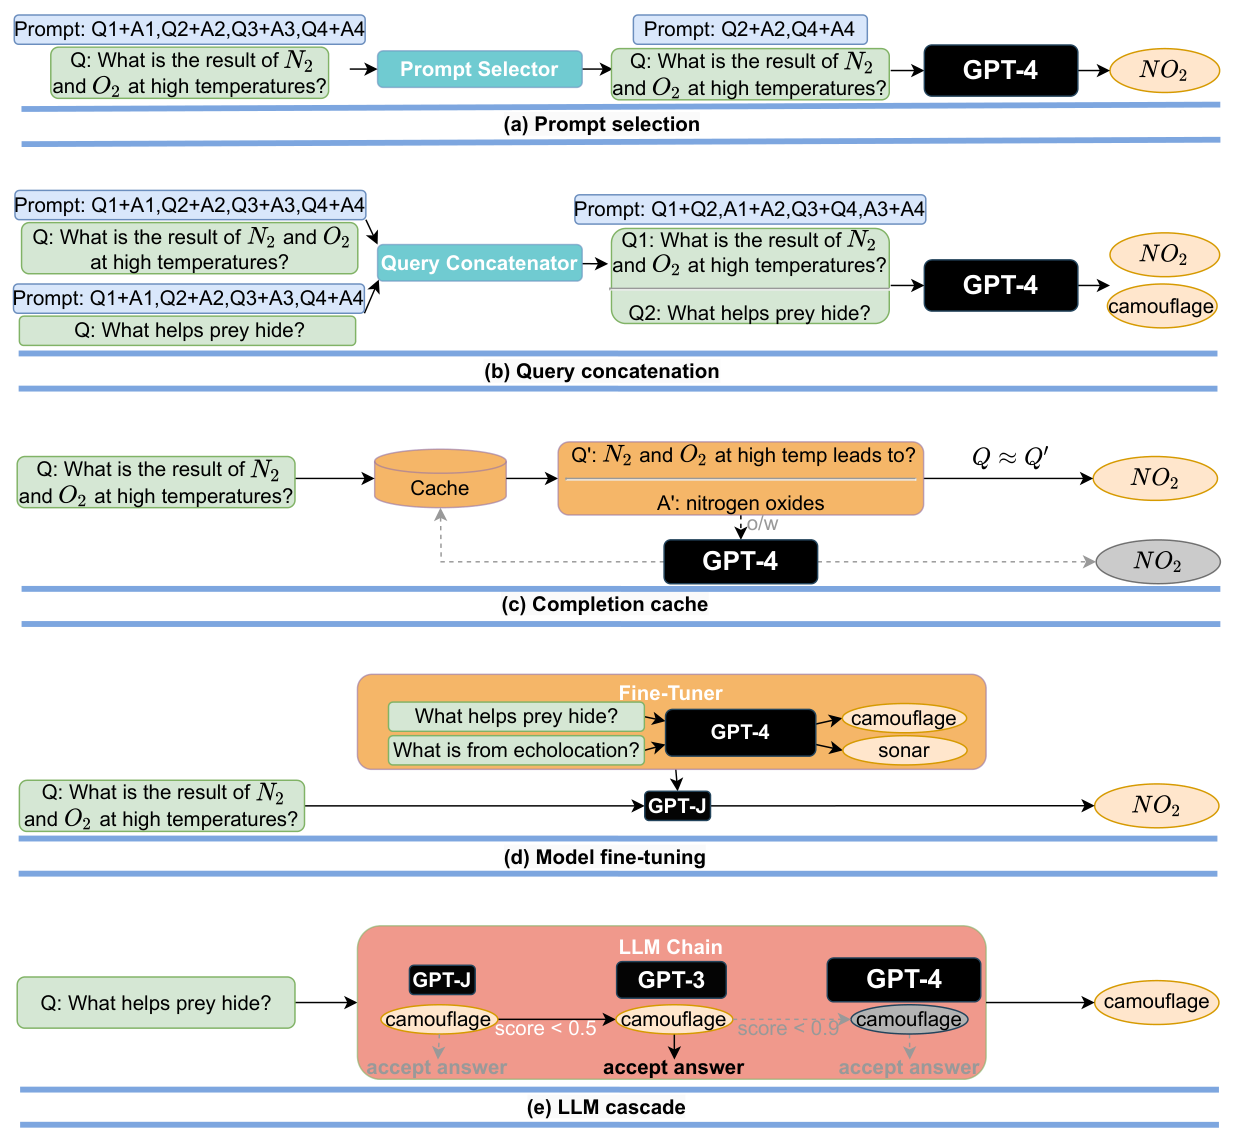

*Там же: пять приёмов в трёх семействах. Адаптация промпта (a, b), приближение сильной модели дешёвой через кэш и дообучение (c, d) и каскад (e). На семинаре собираем каскад*

In [156]:
class Confident(BaseModel):
    reasoning: str = Field(description="ход решения в два-три предложения")
    final: str = Field(description="только итоговый ответ")
    confidence: float = Field(description="честная уверенность в ответе от 0 до 1")

MEMO = {}

def confident_answer(task, model):
    key = (task["id"], model)
    if key not in MEMO:
        before = ledger.total
        try:
            ans = ask_structured(task["question"], model, Confident)
            MEMO[key] = {"final": ans.final, "confidence": ans.confidence, "correct": is_correct(task, ans.final)}
        except Exception:
            MEMO[key] = {"final": "", "confidence": 0.0, "correct": False}
        MEMO[key]["cost"] = ledger.total - before
    return dict(MEMO[key])

In [164]:
def cascade(task, threshold):
    cheap = confident_answer(task, MODELS['cheap'])
    if cheap["confidence"] >= threshold:
        return {**cheap, "escalated": False}
    strong = confident_answer(task, MODELS['strong'])
    return {**strong, "cost": cheap["cost"] + strong["cost"], "escalated": True}


In [165]:
def cascade_sweep(tasks, thresholds):
    rows = []
    for th in thresholds:
        outs = [cascade(t, th) for t in tasks]
        rows.append({"threshold": th, "accuracy": sum(o["correct"] for o in outs) / len(outs),
                     "cost_per_task": sum(o["cost"] for o in outs) / len(outs),
                     "escalated": sum(o["escalated"] for o in outs) / len(outs)})
    df = pd.DataFrame(rows)
    df["cost_per_correct"] = df["cost_per_task"] / df["accuracy"].replace(0, float("nan"))
    return df.round(5)

def cascade_chart(df):
    fig, ax = plt.subplots(figsize=(7, 4.2))
    ax.plot(df["cost_per_task"] * 100, df["accuracy"] * 100, marker="o", color=COLORS["red"])
    for _, r in df.iterrows():
        ax.annotate(f"порог {r['threshold']}, наверх {r['escalated']:.0%}", (r["cost_per_task"] * 100, r["accuracy"] * 100),
                    xytext=(6, -12), textcoords="offset points", fontsize=8)
    ax.set_xlabel("цена задачи, центы")
    ax.set_ylabel("доля верных, %")
    ax.grid(alpha=0.3)
    return fig

def confidence_chart(tasks, model):
    df = pd.DataFrame([confident_answer(t, model) for t in tasks])
    fig, ax = plt.subplots(figsize=(6.5, 3.4))
    ax.hist(df[df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["teal"], label="верные")
    ax.hist(df[~df["correct"]]["confidence"], bins=10, range=(0, 1), alpha=0.7, color=COLORS["red"], label="неверные")
    ax.set_xlabel("заявленная уверенность")
    ax.set_ylabel("задач")
    ax.legend()
    ax.grid(alpha=0.3)
    return fig

In [ ]:
cascade_tasks = load_tasks("fresh_2026.jsonl")[5:25]
cascade_df = cascade_sweep(cascade_tasks, [0.0, 0.7, 0.85, 0.95, 1.01])
cascade_df